In [ ]:
# Run in conda ibiz environment
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import os
import pyproj
from scipy.spatial import cKDTree

# importlib seems to clutter the kernel

# CONFIGS
from preprocess_radargrams_configs import PATH_2016_AN_UTIG_ER2HI1B, PATH_2016_AN_UTIG_ER2HI2, CODE_1B, CODE_2
from preprocess_radargrams_configs import ROWS_CLIPPED_BLANKING
from preprocess_radargrams_configs import AMPLITUDE_VMIN, AMPLITUDE_VMAX, COLOR_MAP
from preprocess_radargrams_configs import IMAGE_TILE_WIDTH, IMAGE_TILE_HEIGHT

In [3]:
# NOTE: Start with 2016 data, as it is more recent and has better coverage
PATH_2016_AN_UTIG_ER2HI1B_folder = os.path.join(PATH_2016_AN_UTIG_ER2HI1B, "2016_AN_UTIG.ER2HI1B")

# Extract the list of .nc files in the folder
list_of_nc_files_2016_UTIG = [
    f for f in os.listdir(PATH_2016_AN_UTIG_ER2HI1B_folder) 
    if f.endswith(".nc")
    ]

list_of_nc_files_2016_UTIG_full_paths = [
    os.path.join(PATH_2016_AN_UTIG_ER2HI1B_folder, f)
    for f in os.listdir(PATH_2016_AN_UTIG_ER2HI1B_folder)
    if f.endswith(".nc")
]

# Proprocessing pipeline for radar data

## Steps
- Start from one image first
    - **high gain** more relevant for bed detection, **low gain** more relevant for surface detection
- Convert to depth
- Extract location of bed 
- crop IBIZ 
- Have a fixed scale
- Combine with bed picks

# Acronyms
- ER2HI1B - ER: EAGLE Radar (?!) - HI: HiCARS - 1B: Level 1B data
- ER2HI2 - ER: EAGLE Radar (?!) - HI: HiCARS - 2: Level 2 data
    - 2016 refers to the 2016/17 season so Jan 2017 is part of it
    - files are considered granules

In [4]:
path_to_a_radargram = list_of_nc_files_2016_UTIG_full_paths[0]

radargram_ds = xr.open_dataset(path_to_a_radargram)
print("Granule ID:", radargram_ds.granule_id)
print("Radargram shape:", radargram_ds["amplitude_high_gain"].shape)
radargram_ds

Granule ID: ER2HI1B_2017024_TOT1_JKB2r_X19a_000
Radargram shape: (4000, 3200)


<xarray.Dataset> Size: 103MB
Dimensions:              (fasttime_dim: 3200, time: 4000)
Coordinates:
  * time                 (time) datetime64[ns] 32kB 2017-01-24T07:55:32.56640...
Dimensions without coordinates: fasttime_dim
Data variables:
    fasttime             (fasttime_dim) float32 13kB ...
    lat                  (time) float32 16kB ...
    lon                  (time) float32 16kB ...
    altitude             (time) float32 16kB ...
    pitch                (time) float32 16kB ...
    roll                 (time) float32 16kB ...
    heading              (time) float32 16kB ...
    amplitude_low_gain   (time, fasttime_dim) float32 51MB ...
    amplitude_high_gain  (time, fasttime_dim) float32 51MB ...
Attributes: (12/27)
    featureType:          timeSeries
    location:             C-GJKB
    source:               airborne ice penetrating radar
    data_version:         JUN292018
    netcdf_version:       4.1.2 of Apr 12 2011 15:15:12 $
    positioning:          transect based Ashtech CA GG24 reciever (no orrieta...
    ...                   ...
    rfparams:             RF PARAMETERS\nCenter Frequency: 60 MHz\nCenter Wav...
    digital:              DIGITAL PARAMETERS\nRecord duration: 64 microsecond...
    TX-record_offset:     Transmit delay from record start: 2.550 microseconds\n
    antenna:              ANTENNA PARAMETERS:\nPlatform: C-GJKB DC-3T aircraf...
    processing:           PROCESSING PARAMETERS\nMode name: pik1\nGoal: emula...
    references:           Peters, M.E., D.D. Blankenship, S.P. Carter, D.A. Y...

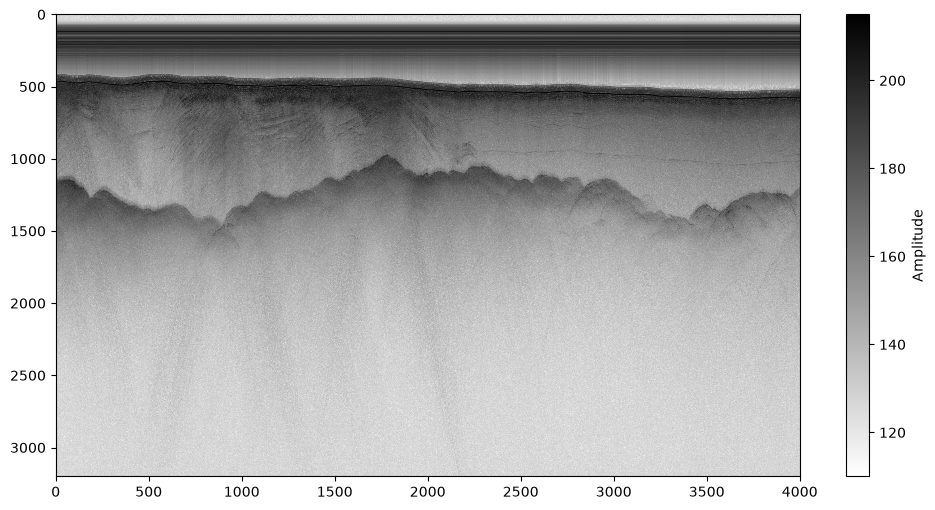

In [7]:
# Visualize the radargram
fig, ax = plt.subplots(figsize = (12, 6))

pcm = ax.pcolormesh(
    # pcolormesh expects input C to be (nrows, ncols) so we have to transpose the data array
    # 400 top rows radargram_ds["amplitude_high_gain"].T[0:400, :],
    radargram_ds["amplitude_high_gain"].T[:, :],
    # global configs for color map and amplitude range
    cmap = COLOR_MAP,
    vmin = AMPLITUDE_VMIN,
    vmax = AMPLITUDE_VMAX
)

# radar convention: surface at top
# Now it is visualised like a table with the origin in the TOP LEFT corner
ax.invert_yaxis() 
plt.colorbar(pcm, ax = ax, label = "Amplitude")
plt.show()

# Find matching L2 data (bed picks)

Granule ID: ER2HI1B_2017024_TOT1_JKB2r_X19a_000

## Construct full path from info we already have 

In [8]:
radargram_grandule_id_L2 = radargram_ds.granule_id[:5] + "2" + radargram_ds.granule_id[7:]
radargram_grandule_id_L2_cropped = radargram_grandule_id_L2[:-3]

PATH_L1B = PATH_2016_AN_UTIG_ER2HI2 + "/" + radargram_grandule_id_L2_cropped + "icethk.txt"
print(PATH_L1B)
# print("/Users/kim.bente/Documents/ANT_QGIS/AADC-DATA/AAS_4346_EAGLE_ICECAP_LEVEL2_AEROGEOPHYSICS/EAGLE-2015-2016-Level2/Level2/2016_AN_UTIG.ER2HI2/ER2HI2_2017024_TOT1_JKB2r_X19a_icethk.txt")

print()
# print the header lines from the L1B text file
with open(PATH_L1B, "r") as f:
    header_lines = [line for line in f if line.startswith("#")]

for line in header_lines:
    print(line, end = "")

/Users/kim.bente/Documents/ANT_QGIS/AADC-DATA/AAS_4346_EAGLE_ICECAP_LEVEL2_AEROGEOPHYSICS/EAGLE-2015-2016-Level2/Level2/2016_AN_UTIG.ER2HI2/ER2HI2_2017024_TOT1_JKB2r_X19a_icethk.txt

# 2016_AN_UTIG ER2HI2 data format
# EAGLE HiCARS 2 L2 Geolocated Ice Thickness
# 
# Field 1: Year (UTC)
# Field 2: Day for year (UTC)
# Field 3: Second of day (UTC)
# Field 4: Longitude (decimal degrees; WGS-84)
# Field 5: Latitude (decimal degrees; WGS-84)
# Field 6: Radar Derived Ice Thickness (meters) (using dielectric of ice of 3.15 and no firn correction)
# Field 7: Radar Derived Surface Range (meters)
# Field 8: Radar Derived Bed Elevation (meters; WGS-84)
# Field 9: Radar Derived Surface Elevation (meters; WGS-84)
# Field 10: Bed reflection coefficient @ 60 MHz (dB wrt perfect reflector; NO ICE LOSS ACCOUNTING)
# Field 11: Surface reflection coefficient @ 60 MHz (dB wrt perfect reflector)
# Field 12: Roll (right wing down positive, degrees)
# 
# Input_data: ER2HI1B
# Input_data: EPUTN1B
# 
# Process

In [9]:
# grab last line for the column headers
col_names = header_lines[-1].lstrip("#").split()
print(col_names)

# now import the data into a pandas dataframe, skipping the header lines, but adding the column names from the last header line
l2_df = pd.read_csv(
    PATH_L1B,
    sep = r"\s+", 
    # skips any line starting with '#'
    comment = "#", 
    header = None, 
    names = col_names,
)

l2_df.head()

['YEAR', 'DOY', 'SOD', 'LON', 'LAT', 'THK', 'SRF_RNG', 'BED_ELEVATION', 'SURFACE_ELEVATION', 'PARTIAL_BED_REFLECT', 'SRF_REFLECT', 'AIRCRAFT_ROLL']


,YEAR,DOY,SOD,LON,LAT,THK,SRF_RNG,BED_ELEVATION,SURFACE_ELEVATION,PARTIAL_BED_REFLECT,SRF_REFLECT,AIRCRAFT_ROLL
0,2017,24,28532.5655,113.872598,-67.610099,1249.84,1029.35,-768.33,481.51,-58.69,-33.18,-9999.0
1,2017,24,28532.8212,113.873047,-67.610024,1244.53,999.59,-733.12,511.41,-57.32,-34.69,-9999.0
2,2017,24,28533.0771,113.873496,-67.609949,1204.04,1002.24,-695.16,508.88,-59.32,-31.16,-9999.0
3,2017,24,28533.3339,113.873947,-67.609874,1205.95,997.76,-692.50,513.45,-55.82,-34.47,-9999.0
4,2017,24,28533.5894,113.874396,-67.609800,1192.47,1001.67,-682.83,509.64,-57.73,-31.19,-9999.0


In [10]:
# summary statistics
l2_df.describe()

,YEAR,DOY,SOD,LON,LAT,THK,SRF_RNG,BED_ELEVATION,SURFACE_ELEVATION,PARTIAL_BED_REFLECT,SRF_REFLECT,AIRCRAFT_ROLL
count,6408.0,6408.0,6408.000000,6408.000000,6408.000000,5882.000000,6408.000000,5881.000000,6408.000000,5709.000000,6388.000000,6408.0
mean,2017.0,24.0,29353.726173,115.294789,-67.354186,1113.753171,1249.826094,-869.162600,247.244257,-56.741505,-13.283707,-9999.0
std,0.0,0.0,474.209049,0.815272,0.148905,226.102440,132.323492,195.007019,136.886577,7.899282,4.247479,0.0
min,2017.0,24.0,28532.565500,113.872598,-67.610099,643.490000,997.760000,-1995.860000,83.880000,-80.760000,-35.610000,-9999.0
25%,2017.0,24.0,28943.144600,114.589418,-67.483058,951.505000,1099.885000,-1001.810000,125.242500,-62.060000,-14.892500,-9999.0
50%,2017.0,24.0,29353.725100,115.301045,-67.356016,1065.705000,1286.185000,-844.510000,205.265000,-58.330000,-12.390000,-9999.0
75%,2017.0,24.0,29764.307325,116.001780,-67.225840,1274.660000,1368.260000,-714.840000,400.442500,-52.010000,-10.600000,-9999.0
max,2017.0,24.0,30174.894000,116.695862,-67.092778,2108.640000,1413.170000,-414.950000,513.450000,-26.330000,-3.160000,-9999.0


## Convert to Polar Stereographic

- to calculate distance

In [11]:
# This is how projections work. check through tool
lonlat_to_polarstereo = pyproj.Transformer.from_crs(crs_from = pyproj.CRS("epsg:4326"),
                                                    crs_to = pyproj.CRS("epsg:3031"),
                                                    always_xy = True) # xy order convention

# Pass lon and lat columns, returns x and y columns in polar stereographic coordinates
x_array, y_array = lonlat_to_polarstereo.transform(l2_df["LON"], l2_df["LAT"])

l2_df["X"] = x_array
l2_df["Y"] = y_array

# Calculate the distance between each point and the next point in the dataframe, using the X and Y columns
distance_to_next = ((l2_df["X"].shift(-1) - l2_df["X"])**2 + (l2_df["Y"].shift(-1) - l2_df["Y"])**2)**0.5
print("Distance to next point in meters:")
print(distance_to_next.describe())

Distance to next point in meters:
count    6407.000000
mean       21.223165
std         0.161063
min        20.764658
25%        21.120740
50%        21.206816
75%        21.292548
max        22.057379
dtype: float64


# Join

Join additional info from L2 onto L1B. This may include:
- bed elevation (subtract bed elevation + flight altitude from L1B to get bed elevation)
    - unclear about surface range
- PARTIAL_BED_REFLECT # Field 10: Bed reflection coefficient @ 60 MHz (dB wrt perfect reflector; NO ICE LOSS ACCOUNTING)
- SRF_REFLECT # Field 11: Surface reflection coefficient @ 60 MHz (dB wrt perfect reflector)

Future:
- Use YEAR and DOY as alternative or additional way to match

# Match via LON LAT

- L1B data is float32
- L2 data is float64. When we simply convert L2 to float32 we match rather well. These are still some numerical issues but a tree and generate a 1:1 match.

In [ ]:
# Overlap of L2 coordinates and radargram coordinates
fig, ax = plt.subplots(figsize = (8, 8))


ax.scatter(l2_df["LON"].values, l2_df["LAT"].values, 
           s = 9, alpha = 0.1, label = "L2 file", c = l2_df.index, cmap = "viridis")
ax.scatter(radargram_ds["lon"].values, radargram_ds["lat"].values, 
           s = 1, alpha = 0.1, label = "radargram (L1B)", c = np.arange(radargram_ds.time.size), cmap = "YlOrRd_r")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.set_title("Radargram vs L2 coordinates")
plt.show()

# Join

In [43]:
# Use consistent dtype (float64) for both — don't force float32
radar_lon = radargram_ds["lon"].values.astype(np.float64)
radar_lat = radargram_ds["lat"].values.astype(np.float64)

l2_lon = l2_df["LON"].values.astype(np.float64)
l2_lat = l2_df["LAT"].values.astype(np.float64)

radar_coords = np.column_stack([radar_lon, radar_lat])
l2_coords = np.column_stack([l2_lon, l2_lat])

# Build tree on l2_df (the side we're pulling matches from)
tree = cKDTree(l2_coords)
tol = 1e-5  # degrees; tune to your data's actual precision/spacing

distances, indices = tree.query(radar_coords, distance_upper_bound = tol)

# distances == inf / indices == len(l2_coords) means "no match found"
has_match = distances < tol

# indices is len(radargram_ds) long, aligned to radar order
# invalid indices point out-of-bounds, so clip/mask them before indexing l2_df
safe_indices = np.where(has_match, indices, 0)  # placeholder for unmatched rows

matched_l2_subset = l2_df.iloc[safe_indices].reset_index(drop = True)

# Null out rows that didn't actually match
matched_l2_subset.loc[~has_match] = np.nan

print(f"Matched: {has_match.sum()} / {len(radar_coords)}")

# Select columns I want to transfer
selected_cols = ["THK", "BED_ELEVATION", "SURFACE_ELEVATION", "PARTIAL_BED_REFLECT", "SRF_REFLECT", "SRF_RNG", "X", "Y"]

for col in selected_cols:
    # along time dim
    radargram_ds[f"l2_{col}"] = ("time", matched_l2_subset[col].values)

# free up memory
del tree

Matched: 4000 / 4000


## Process L1B - Convert fasttime to meters

- Fasttime 3200 x Time 4000
- fasttime is 2-way travel time in µseconds
- Conversion differs for air and ice so do a dual approach
- every column will consequently have a sightly different converion of fasttime

In [13]:
print("Fasttime units:")
print(radargram_ds.fasttime.long_name)
print()
print("Amplitude high gain units:")
print(radargram_ds.amplitude_high_gain.units)
print()
print(radargram_ds.amplitude_high_gain)
 # counts in dB

Fasttime units:
2-way travel time in µseconds

Amplitude high gain units:
counts in dB

<xarray.DataArray 'amplitude_high_gain' (time: 4000, fasttime_dim: 3200)> Size: 51MB
[12800000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 32kB 2017-01-24T07:55:32.566406250 ... 201...
Dimensions without coordinates: fasttime_dim
Attributes:
    units:      counts in dB
    long_name:  Amplitude of high gain radar reflection after processing


In [14]:
# speed of light in vacuum
c = 2.998e8  # m/s

# relative permittivity (epsilon_r) of ice (~ 3.15 is standard for glacial ice)
epsilon_ice = 3.15

# refractive index of ice
n = np.sqrt(epsilon_ice)

# speed of light in ice
v_ice = c / n 

# --- Air gap handling ---
# "free air content" = one-way distance from antenna to surface, in meters
air_gap_m = radargram_ds.altitude.values - radargram_ds.l2_SURFACE_ELEVATION.values  # plane altitude above surface

# Two-way travel time spent in air (round trip through air only, given air gap in meters and speed of light in vacuum)
# Maybe 10% of time air travel
air_twtt_seconds = (2 * air_gap_m) / c

# Convert fasttime (TWTT, in microseconds) to seconds
fasttime_in_seconds = radargram_ds.fasttime.values * 1e-6

# Subtract the air portion, leaving only the ice portion of the TWTT
# fasttime_in_seconds is a column vector (y-axis), air_twtt_seconds is a row vector (x-axis), so we can broadcast the subtraction to get a 2D array of ice TWTT values
# NOTE: negative values mean time still in air, so we can mask those out later if needed
ice_twtt_seconds = fasttime_in_seconds.ravel()[:, np.newaxis] - air_twtt_seconds.ravel()[np.newaxis, :]

# --- Mask: True where sample is still in air (before surface return) ---
in_air_mask = ice_twtt_seconds < 0

# Container
one_way_distance_m = np.empty_like(ice_twtt_seconds)

# Fill air bins only: one way distance from altitude
one_way_distance_m[in_air_mask] = c * fasttime_in_seconds[:, np.newaxis].repeat(ice_twtt_seconds.shape[1], axis = 1)[in_air_mask] / 2

# Fill ice bins only
# Note: Maybe use cell atop
one_way_distance_m[~ in_air_mask] = (air_gap_m[np.newaxis, :] + v_ice * ice_twtt_seconds / 2)[~ in_air_mask]

# Get elevation above sea level (m) for each sample in the radargram, by subtracting the one-way distance from the plane altitude
elevation_m = radargram_ds.altitude.values[None, :] - one_way_distance_m

In [15]:
# Consistency check:
residual = radargram_ds["altitude"] - radargram_ds["l2_SRF_RNG"] - radargram_ds["l2_SURFACE_ELEVATION"]
np.max(np.abs(residual))

<xarray.DataArray ()> Size: 8B
array(0.00508789)
Attributes:
    standard_name:  height
    units:          meters
    positive:       up
    long_name:      Altitude of antenna above nominal sea level (WGS84)

In [ ]:
print(ROWS_CLIPPED_BLANKING)

in_air_mask_shifted = np.pad(
    in_air_mask,
    pad_width = ((ROWS_CLIPPED_BLANKING, 0), (0, 0)),  # pad ROWS_CLIPPED_BLANKING rows at top, 0 at bottom
    mode = "constant",
    constant_values = False
)[:-ROWS_CLIPPED_BLANKING, :]

print("in_air_mask shape:", in_air_mask.shape)

125
in_air_mask shape: (3200, 4000)


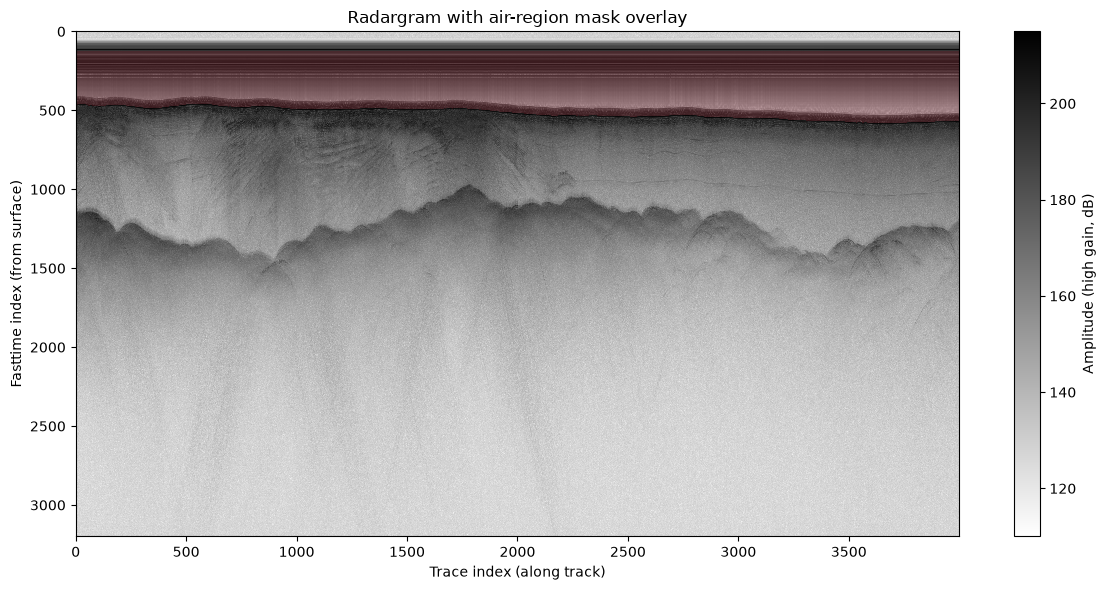

In [21]:
fig, ax = plt.subplots(figsize = (12, 6))

# Transpose amplitude values to match pcolormesh's (nrows, ncols) convention
# amplitude shape: (3200, 4000) 
amplitude = radargram_ds["amplitude_high_gain"].values.T 

# this x axis is easier for indexing/zooming
fasttime_idx = np.arange(radargram_ds.fasttime.values.shape[0])                     
trace_idx = np.arange(amplitude.shape[1])          

mesh = ax.pcolormesh(trace_idx, fasttime_idx, amplitude, shading = "auto", cmap = COLOR_MAP, vmin = AMPLITUDE_VMIN, vmax = AMPLITUDE_VMAX)
fig.colorbar(mesh, ax = ax, label = "Amplitude (high gain, dB)")

# Overlay mask where we make 0's transparent (NaN) and 1's red
mask_overlay = np.where(in_air_mask_shifted, 1, np.nan) 
ax.pcolormesh(trace_idx, fasttime_idx, mask_overlay, shading = "auto", cmap = "Reds", alpha = 0.3, vmin = 0, vmax = 1)

ax.set_xlabel("Trace index (along track)")
ax.set_ylabel("Fasttime index (from surface)")
ax.set_title("Radargram with air-region mask overlay")

# Zoom by uncommenting this
# ax.set_ylim(400, 600)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
print("in_air_mask shape:", in_air_mask.shape)
print("amplitude shape:", amplitude.shape)
print("Number of True (in-air) cells:", in_air_mask.sum())
print("Total cells:", in_air_mask.size)
print("Fraction in air:", in_air_mask.sum() / in_air_mask.size)

in_air_mask shape: (3200, 4000)
amplitude shape: (3200, 4000)
Number of True (in-air) cells: 1568733
Total cells: 12800000
Fraction in air: 0.122557265625


### Offset check

In [ ]:
fasttime_us = radargram_ds.fasttime.values  # shape (n_fasttime,)
dt_us = fasttime_us[1] - fasttime_us[0]      # sample spacing in microseconds
dt_s = dt_us * 1e-6

# Expected row index of the surface return, per trace
expected_surface_row = air_twtt_seconds / dt_s   # air_twtt_seconds already in seconds, shape (n_traces,)

# exclude high-amp first rows
amp = radargram_ds.amplitude_low_gain.values.T[350:, :]

# crude but effective: row of max amplitude per trace = surface return
observed_surface_row = np.argmax(amp, axis = 0)  # shape (n_traces,)
observed_surface_row
# 350 + 121 - 343 = 128

array([121, 111, 112, ..., 221, 221, 221], shape=(4000,))

# Plot radargram with bed picks

In [67]:
bed_elevation[175]

np.float64(nan)

In [73]:
# 1. Retrieve interpreted bed elevation from L2 file (in meters above sea level)
# shape (4000,)
# NOTE: some of the bed elevation values are NaN, so we need to handle that
bed_elevation = radargram_ds.l2_BED_ELEVATION.values 

# 2. For each column, find the row index where elevation_m is closest to bed_elevation
# NOTE: we need floats to allow for NaN values, so we cast to float
bed_idx_no_offset = np.argmin(np.abs(elevation_m - bed_elevation[np.newaxis, :]), axis = 0).astype(float)

# Propagate NaN where bed_elevation itself was NaN
bed_idx_no_offset[np.isnan(bed_elevation)] = np.nan

# 3. Add the offset for the clipped blanking rows to get the final bed index
bed_idx = bed_idx_no_offset + ROWS_CLIPPED_BLANKING
print("bed_idx shape:", bed_idx.shape) 

# 4. Create a boolean mask for the bed locations
x_axis_index = np.arange(elevation_m.shape[1])
# container
bed_mask = np.zeros_like(elevation_m, dtype = bool)
# set to 1
# some nan values are shown as 0
bed_mask[bed_idx.astype(int), x_axis_index] = True

bed_idx shape: (4000,)


/var/folders/pv/_mchxpdj3tz_s_9735cr69pr0000gp/T/ipykernel_35832/71242852.py:23: RuntimeWarning: invalid value encountered in cast
  bed_mask[bed_idx.astype(int), x_axis_index] = True


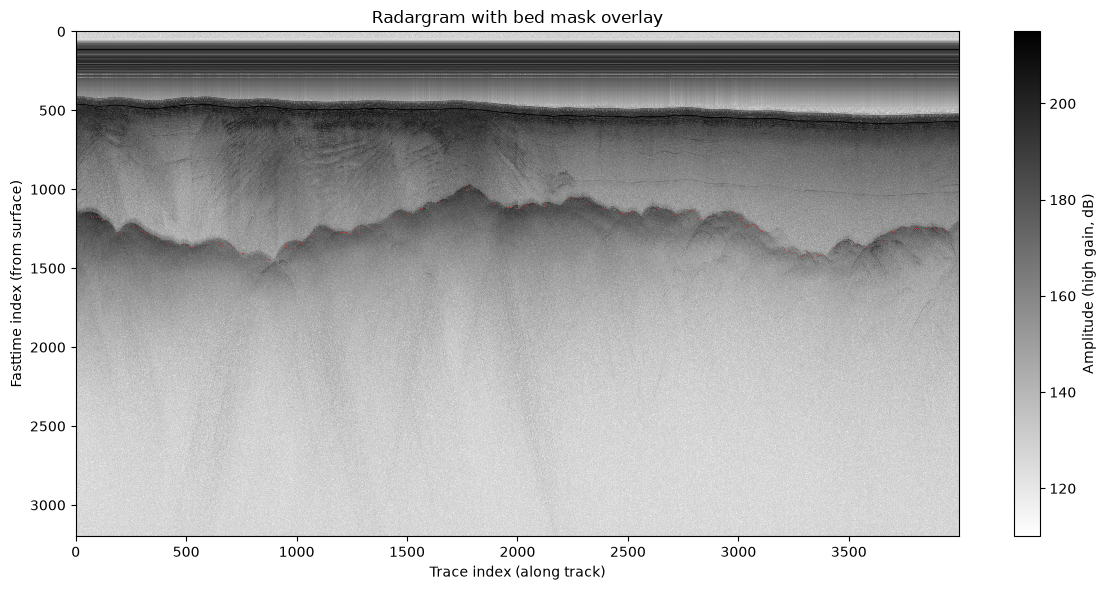

In [29]:
fig, ax = plt.subplots(figsize = (12, 6))

# Transpose amplitude values to match pcolormesh's (nrows, ncols) convention
# amplitude shape: (3200, 4000) 
amplitude = radargram_ds["amplitude_high_gain"].values.T 

# this x axis is easier for indexing/zooming
fasttime_idx = np.arange(radargram_ds.fasttime.values.shape[0])                     
trace_idx = np.arange(amplitude.shape[1])          

mesh = ax.pcolormesh(trace_idx, fasttime_idx, amplitude, shading = "auto", cmap = COLOR_MAP, vmin = AMPLITUDE_VMIN, vmax = AMPLITUDE_VMAX)
fig.colorbar(mesh, ax = ax, label = "Amplitude (high gain, dB)")

# Overlay mask where we make 0's transparent (NaN) and 1's red
mask_overlay = np.where(bed_mask, 1, np.nan) 
ax.pcolormesh(trace_idx, fasttime_idx, mask_overlay, shading = "auto", cmap = "Reds", alpha = 1.0, vmin = 0, vmax = 1.5)

ax.set_xlabel("Trace index (along track)")
ax.set_ylabel("Fasttime index (from surface)")
ax.set_title("Radargram with bed mask overlay")

# Zoom by uncommenting this
# ax.set_ylim(1000, 1500)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [64]:
bedel = radargram_ds.l2_BED_ELEVATION

# Crop tiles

- Naming: radar granule + x_axis index
- Along-track span
- Depth span

In [82]:
x_max_index

336

In [ ]:
IMAGE_TILE_WIDTH = 336
IMAGE_TILE_HEIGHT = IMAGE_TILE_WIDTH

HALF_TILE_WIDTH = IMAGE_TILE_WIDTH // 2
HALF_TILE_HEIGHT = IMAGE_TILE_HEIGHT // 2

PLOT_TILES_BOOL = False

for x_idx in range(HALF_TILE_WIDTH, amplitude.shape[1] - HALF_TILE_WIDTH, 1):
    print(x_idx)
    x_center_index = x_idx

    x_min_index = x_center_index - HALF_TILE_WIDTH
    print("x_min_index:", x_min_index)
    x_max_index = x_center_index + HALF_TILE_WIDTH
    print("x_max_index:", x_max_index)

    # Y CENTER INDEX
    y_center_index = bed_idx[x_center_index].item()
    
    if np.isnan(y_center_index):
        print(f"Skipping x_idx {x_idx}: no valid bed pick")
        # Skips rest of loop
        continue

    # NOTE: Needs to be an integer for indexing, but bed_idx can be float due to NaN handling
    y_center_index = int(y_center_index)

    # get indices for the tile
    y_min_index = y_center_index - HALF_TILE_HEIGHT 
    y_max_index = y_center_index + HALF_TILE_HEIGHT

    x_min_ps, x_max_ps, y_min_ps, y_max_ps = radargram_ds.l2_X[x_min_index, ].values, radargram_ds.l2_X[x_max_index, ].values, radargram_ds.l2_Y[y_min_index, ].values, radargram_ds.l2_Y[y_max_index, ].values
    along_track_span = np.sqrt((x_max_ps - x_min_ps)**2 + (y_max_ps - y_min_ps)**2)
    # along track span in meters. e.g. 336 pixels * 21 m/pixel = 7 km
    print(f"along_track_span in meters: {along_track_span:.1f}")

    # Indicate vertical span of the tile for the (x axis) center of the tile
    vertical_span = elevation_m[y_min_index, x_center_index] - elevation_m[y_max_index, x_center_index]
    print(f"vertical_span in meters: {vertical_span:.1f}")

    tile = amplitude[y_min_index : y_max_index, x_min_index : x_max_index]
    print("tile shape:", tile.shape)

    if PLOT_TILES_BOOL:
        fig, ax = plt.subplots(figsize = (8, 6))
        mesh = ax.pcolormesh(tile, shading = "auto", cmap = COLOR_MAP, vmin = AMPLITUDE_VMIN, vmax = AMPLITUDE_VMAX)

        # Mark the center (bed pick location)
        ax.plot(HALF_TILE_WIDTH, HALF_TILE_HEIGHT, marker = "+", color = "red", markersize = 15, markeredgewidth = 2)

        fig.colorbar(mesh, ax = ax, label = "Amplitude (dB)")
        ax.invert_yaxis()
        ax.set_aspect("equal")
        plt.show()

168
x_min_index: 0
x_max_index: 336
along_track_span in meters: 7139.2
vertical_span in meters: 567.6
tile shape: (336, 336)
169
x_min_index: 1
x_max_index: 337
along_track_span in meters: 7139.4
vertical_span in meters: 567.6
tile shape: (336, 336)
170
x_min_index: 2
x_max_index: 338
along_track_span in meters: 7142.5
vertical_span in meters: 567.6
tile shape: (336, 336)
171
x_min_index: 3
x_max_index: 339
along_track_span in meters: 7139.5
vertical_span in meters: 567.6
tile shape: (336, 336)
172
x_min_index: 4
x_max_index: 340
along_track_span in meters: 7140.3
vertical_span in meters: 567.6
tile shape: (336, 336)
173
x_min_index: 5
x_max_index: 341
along_track_span in meters: 7140.3
vertical_span in meters: 567.6
tile shape: (336, 336)
174
x_min_index: 6
x_max_index: 342
along_track_span in meters: 7142.3
vertical_span in meters: 567.6
tile shape: (336, 336)
175
x_min_index: 7
x_max_index: 343
Skipping x_idx 175: no valid bed pick
176
x_min_index: 8
x_max_index: 344
Skipping x_idx 

x_min_index: 1232
x_max_index: 1568
along_track_span in meters: 7134.6
vertical_span in meters: 567.6
tile shape: (336, 336)


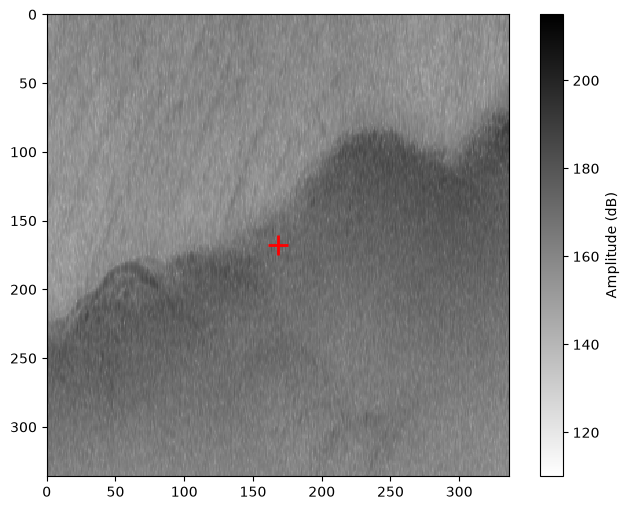

In [91]:
x_idx = 1400
x_center_index = x_idx

x_min_index = x_center_index - HALF_TILE_WIDTH
print("x_min_index:", x_min_index)
x_max_index = x_center_index + HALF_TILE_WIDTH
print("x_max_index:", x_max_index)

# Y CENTER INDEX
y_center_index = bed_idx[x_center_index].item()

# NOTE: Needs to be an integer for indexing, but bed_idx can be float due to NaN handling
y_center_index = int(y_center_index)

# get indices for the tile
y_min_index = y_center_index - HALF_TILE_HEIGHT 
y_max_index = y_center_index + HALF_TILE_HEIGHT

x_min_ps, x_max_ps, y_min_ps, y_max_ps = radargram_ds.l2_X[x_min_index, ].values, radargram_ds.l2_X[x_max_index, ].values, radargram_ds.l2_Y[y_min_index, ].values, radargram_ds.l2_Y[y_max_index, ].values
along_track_span = np.sqrt((x_max_ps - x_min_ps)**2 + (y_max_ps - y_min_ps)**2)
# along track span in meters. e.g. 336 pixels * 21 m/pixel = 7 km
print(f"along_track_span in meters: {along_track_span:.1f}")

# Indicate vertical span of the tile for the (x axis) center of the tile
vertical_span = elevation_m[y_min_index, x_center_index] - elevation_m[y_max_index, x_center_index]
print(f"vertical_span in meters: {vertical_span:.1f}")

tile = amplitude[y_min_index : y_max_index, x_min_index : x_max_index]
print("tile shape:", tile.shape)

fig, ax = plt.subplots(figsize = (8, 6))
mesh = ax.pcolormesh(tile, shading = "auto", cmap = COLOR_MAP, vmin = AMPLITUDE_VMIN, vmax = AMPLITUDE_VMAX)

# Mark the center (bed pick location)
ax.plot(HALF_TILE_WIDTH, HALF_TILE_HEIGHT, marker = "+", color = "red", markersize = 15, markeredgewidth = 2)

fig.colorbar(mesh, ax = ax, label = "Amplitude (dB)")
ax.invert_yaxis()
ax.set_aspect("equal")
plt.show()

# Questions:
- Offset choice
- Use reflectivity and other for correlation analysis (after) or also for processing?
- Build corresponding meta data tensor (index) and image dataset

# METADATA

- vertical span
- horizontal span
- relative reflectively
- lon lat
- x y